In [203]:
%pip install pyomo

Note: you may need to restart the kernel to use updated packages.


In [204]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import math
import pyomo.environ as pyo

### Data cleaning

In [205]:
df = pd.read_csv("ratings.csv")

df_est = df.copy()

df_est["ortg"] = (df_est["ortg"] - df_est["ortg"].mean()) / df_est["ortg"].std()
df_est["drtg"] = (df_est["drtg"] - df_est["drtg"].mean()) / df_est["drtg"].std()
df_est["netrtg"] = (df_est["netrtg"] - df_est["netrtg"].mean()) / df_est["netrtg"].std()
df_est["proj_wins"] = 2 * (df_est["proj_wins"] - df_est["proj_wins"].mean()) / df_est["proj_wins"].std()

### Modelo con victorias esperadas

In [206]:
kmeans = KMeans(n_clusters=4, random_state=0)

In [207]:
x = df_est[["netrtg","proj_wins"]]
kmeans.fit(x)

df["cluster"] = kmeans.labels_
df.to_csv("ratings_cluster.csv")
df.sort_values(by="proj_wins",ascending=False)

c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,team,ortg,drtg,netrtg,proj_wins,cluster
14,Oklahoma City Thunder,120.3,107.5,12.8,62.5,3
18,Cleveland Cavaliers,121.7,112.2,9.5,56.5,3
10,Denver Nuggets,119.9,116.0,3.9,53.5,3
1,New York Knicks,118.5,114.3,4.2,53.5,3
13,Houston Rockets,115.3,110.8,4.6,52.5,3
27,Orlando Magic,109.4,109.6,-0.1,51.5,0
24,Minnesota Timberwolves,116.6,111.5,5.1,49.5,0
17,Los Angeles Clippers,115.1,110.3,4.7,49.5,0
2,Golden State Warriors,115.0,111.7,3.3,47.5,0
6,Atlanta Hawks,114.6,115.7,-1.1,47.5,0


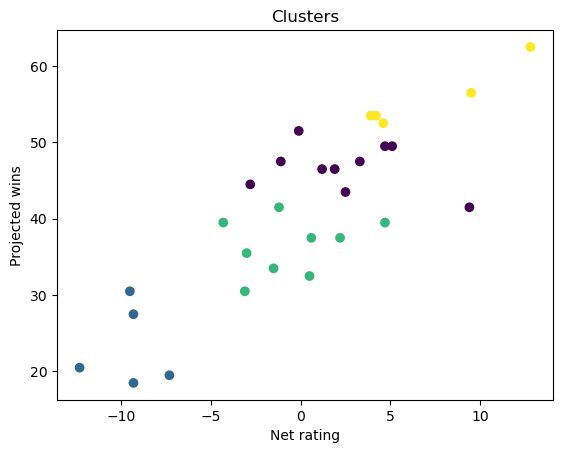

In [208]:
plt.scatter(df["netrtg"], df["proj_wins"], c=df["cluster"])
plt.xlabel("Net rating")
plt.ylabel("Projected wins")
plt.title("Clusters")
plt.show()

In [209]:
df.groupby(by="cluster")["netrtg"].mean()

cluster
0    2.410000
1   -9.540000
2   -0.566667
3    7.000000
Name: netrtg, dtype: float64

In [210]:
# The 76ers have 98.17 possessions per game bewteen the 20-21 and 24-25 seasons
# Average league possessions is 99-100 per game
# We can use net rating to estimate the probability of the 76ers winning against the different clusters

net_embiid = 5.4
net_not_embiid = -3.7

poss = 98.17
# Standard deviation of possessions per game
sigma = 12

# Añadir algo en casa y fuera
# Record con Embiid en casa: 94-37. Net rating: 6.4
# Record sin Embiid en casa: 25-44. Net rating: -3.7
# Record con Embiid fuera: 72-40. Net rating: 4.2
# Record sin Embiid fuera: 34-54. Net rating: -3.8

# Differences of net ratings with clusters if Embiid plays or not
diffs_embiid = [net_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]
diffs_not_embiid = [net_not_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_embiid]
win_not_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_not_embiid]

win_probs, win_not_probs

# Against cluster 1: 14
# Against cluster 2: 28
# Against cluster 3: 25
# Against cluster 4: 15

# Todos oeste -> 2 partidos (30)
# Todos division (Raptors, Celtics, Knicks, Nets) -> 4 partidos (16)
# Resto -> Contra 6 4 partidos, contra 4 3 partidos (36)
# Magic –> 3
# Heat –> 3
# Wizards -> 4
# Hornets -> 3
# Hawks -> 3
# Bulls -> 3 (+1)
# Bucks -> 4
# Pacers -> 3 (+1)
# Cavs -> 4
# Pistons -> 4

# Cluster nuevo
# Con Embiid -> 53 victorias en 82 partidos
# Sin Embiid -> 31 victorias en 82 partidos

([0.5966195959965248,
  0.8891871170976309,
  0.6872686593350312,
  0.44792984426918747],
 [0.3085907319380298,
  0.6835897202682024,
  0.39884694475545124,
  0.19069197482712835])

### Modelo muy basado en temporada anterior

In [211]:
kmeans_alt = KMeans(n_clusters=4, random_state=0)
x_alt = df_est[["ortg","drtg","netrtg"]]
kmeans_alt.fit(x_alt)

c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4, random_state=0)

In [212]:
df_alt = df.copy()
df_alt["cluster"] = kmeans_alt.labels_
df_alt

,team,ortg,drtg,netrtg,proj_wins,cluster
0,Boston Celtics,120.6,111.1,9.4,41.5,3
1,New York Knicks,118.5,114.3,4.2,53.5,0
2,Golden State Warriors,115.0,111.7,3.3,47.5,0
3,Detroit Pistons,115.0,113.1,1.9,46.5,0
4,Los Angeles Lakers,115.9,114.7,1.2,46.5,0
5,Sacramento Kings,116.7,116.2,0.5,32.5,2
6,Atlanta Hawks,114.6,115.7,-1.1,47.5,2
7,Washington Wizards,106.8,119.1,-12.3,20.5,1
8,Chicago Bulls,114.1,115.6,-1.5,33.5,2
9,San Antonio Spurs,114.4,117.2,-2.8,44.5,2


In [213]:
df_alt.groupby(by="cluster")["netrtg"].mean()

cluster
0     2.984615
1    -9.540000
2    -2.062500
3    10.566667
Name: netrtg, dtype: float64

In [214]:
# The 76ers have 98.17 possessions per game bewteen the 20-21 and 24-25 seasons
# Average league possessions is 99-100 per game
# We can use net rating to estimate the probability of the 76ers winning against the different clusters

net_embiid = 5.4
net_not_embiid = -3.7

poss = 98.17
# Standard deviation of difference of points per game
# Con 12 funciona bastante bien
sigma = 12

# Suponiendo que el margen real sigue (aprox.) una distribución normal, 
# la probabilidad de ganar es la probabilidad de que el margen sea > 0

# Añadir algo en casa y fuera
# Record con Embiid en casa: 94-37. Net rating: 6.4
# Record sin Embiid en casa: 25-44. Net rating: -3.7
# Record con Embiid fuera: 72-40. Net rating: 4.2
# Record sin Embiid fuera: 34-54. Net rating: -3.8

# Differences of net ratings with clusters if Embiid plays or not
diffs_embiid = [net_embiid - net for net in df_alt.groupby(by="cluster")["netrtg"].mean()]
diffs_not_embiid = [net_not_embiid - net for net in df_alt.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_embiid]
win_not_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_not_embiid]

win_probs, win_not_probs

# Cluster antiguo
# Con Embiid -> 51 victorias en 80 partidos
# Sin Embiid -> 30/31 victorias en 80 partidos

([0.5783204308644903,
  0.8891871170976309,
  0.7292329192536076,
  0.33626569229347963],
 [0.29223840603526946,
  0.6835897202682024,
  0.446716649286113,
  0.12157848850214237])

### Separación casa/fuera

In [215]:
# The 76ers have 98.17 possessions per game bewteen the 20-21 and 24-25 seasons
# Average league possessions is 99-100 per game
# We can use net rating to estimate the probability of the 76ers winning against the different clusters

# Record con Embiid en casa: 94-37. Net rating: 6.4
# Record sin Embiid en casa: 25-44. Net rating: -3.7
# Record con Embiid fuera: 72-40. Net rating: 4.2
# Record sin Embiid fuera: 34-54. Net rating: -3.8

net_home_embiid = 6.4
net_home_not_embiid = -3.7
net_away_embiid = 4.2
net_away_not_embiid = -3.8

poss = 98.17
# Standard deviation of difference of points per game
# Con 12 funciona bastante bien
sigma = 12

# Todos oeste -> 2 partidos (30)
# Todos division (Raptors, Celtics, Knicks, Nets) -> 4 partidos (16)
# Resto -> Contra 6 4 partidos, contra 4 3 partidos (36)
# Magic –> 3
# Heat –> 3 (+1)
# Wizards -> 4
# Hornets -> 3
# Hawks -> 3
# Bulls -> 3
# Bucks -> 4
# Pacers -> 3 (+1)
# Cavs -> 4
# Pistons -> 4

# Hay que poner como constraint que no juegue en Denver por favor
# Lleva sin jugar desde el 8 de noviembre de 2019 🤣

In [216]:
# At home: 41
# Against cluster 1: 7
# Against cluster 2: 15
# Against cluster 3: 12
# Against cluster 4: 7

# Differences of net ratings with clusters if Embiid plays or not AT HOME
diffs_home_embiid = [net_home_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]
diffs_home_not_embiid = [net_home_not_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_home_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_home_embiid]
win_home_not_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_home_not_embiid]

win_home_embiid_probs, win_home_not_embiid_probs

# En casa con Embiid: 27/28 victorias de 41
# En casa sin Embiid: 15/16 victorias de 41

([0.6279448994938123,
  0.9038874422925967,
  0.7156378828027741,
  0.4804257786319578],
 [0.3085907319380298,
  0.6835897202682024,
  0.39884694475545124,
  0.19069197482712835])

In [217]:
# Away: 41
# Against cluster 1: 7
# Against cluster 2: 13
# Against cluster 3: 13
# Against cluster 4: 8

# Differences of net ratings with clusters if Embiid plays or not AWAY
diffs_away_embiid = [net_away_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]
diffs_away_not_embiid = [net_away_not_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_away_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_away_embiid]
win_away_not_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_away_not_embiid]

win_away_embiid_probs, win_away_not_embiid_probs

# Fuera con Embiid: 25/26 victorias de 41
# Fuera sin Embiid: 15/16 victorias de 41

([0.5582117569389846,
  0.8695033501188123,
  0.6517143697163756,
  0.40940984578293965],
 [0.30571623988778884,
  0.6806723822265628,
  0.3956920890266532,
  0.18847499049271899])

In [218]:
# Total: 
# Con Embiid: 54/56 victorias de 82
# Sin Embiid: 30/32 victorias de 82

### Ideas de constraints

In [219]:
# Si Embiid juega menos de 24-27 minutos es como si no jugara (para eso mejor que no juegue)
# A partir de ahí regresión lineal hasta 36-37-38 minutos -> va aumentando la probabilidad según juegue más
# Embiid tiene 33.1 minutos por partido entre las temporadas 20-21 y 24-25
# Su máximo en una temporada son 34.6 en la 22-23, cuando fue MVP
# Si juega más de X minutos en un partido no puede jugar el siguiente
# En vez de no jugar el siguiente partido, podría ser que los minutos acumulados pesaran más de cara a calcular la probabilidad de lesión
# Los 76ers deben ganar un número mínimo de partidos para clasificar a playoffs (por definir, yo diria unas 50)
# Partidos de copa -> Embiid tiene que jugarlos obligatoriamente -> sanción
# Si juega menos minutos de los que le gustaría en la temporada pedirá el traspaso
# No puede jugar en Denver (jajajaja)

# MINIMIZAR minutos jugados por Embiid en la temporada
# Igual seria buena idea ignorar lo de que si no juega suficiente se enfadará y pedirá el traspaso (lo veo complicado de modelar)

# Modelado de nuestro modelo

![Model Approach](model_approach.jpg)

### Parámetros

##### Calculo de parametro $P_{gr}$ (Games x Rating/Cluster)
Extraemos los datos del calendario y cruzamos con los clusters calculados para obtener una matriz donde $M_{g,r} = 1$ si el juego $g$ es contra un equipo del cluster $r$.

In [220]:
# 1. Recuperar los clusters (re-calculando para asegurar que tenemos la asignación correcta)
df_ratings = pd.read_csv("ratings.csv")
df_est = df_ratings.copy()

# Normalización idéntica al bloque anterior
df_est["ortg"] = (df_est["ortg"] - df_est["ortg"].mean()) / df_est["ortg"].std()
df_est["drtg"] = (df_est["drtg"] - df_est["drtg"].mean()) / df_est["drtg"].std()
df_est["netrtg"] = (df_est["netrtg"] - df_est["netrtg"].mean()) / df_est["netrtg"].std()
df_est["proj_wins"] = 2 * (df_est["proj_wins"] - df_est["proj_wins"].mean()) / df_est["proj_wins"].std()

# K-Means
kmeans_opt = KMeans(n_clusters=4, random_state=0)
kmeans_opt.fit(df_est[["netrtg", "proj_wins"]])
df_ratings["cluster"] = kmeans_opt.labels_

# 2. Cargar Schedule y Mapear
df_schedule = pd.read_csv("schedule.csv")

# Diccionario de mapeo
team_to_cluster = dict(zip(df_ratings["team"], df_ratings["cluster"]))

# Mapear oponente a cluster
df_schedule["Opponent_Cluster"] = df_schedule["Opponent"].map(team_to_cluster)

# Verificar si hay nulos (nombres que no coinciden)
missing = df_schedule[df_schedule["Opponent_Cluster"].isna()]
if not missing.empty:
    print("Warning: Los siguientes equipos no se encontraron en ratings:", missing["Opponent"].unique())

# 3. Crear Matriz Binaria (One-Hot)
# Obtenemos dummies para las columnas de clusters (0, 1, 2, 3)
matrix = pd.get_dummies(df_schedule["Opponent_Cluster"]).astype(int)

# Aseguramos que tenemos columas para todos los clusters 0,1,2,3
for c in [0, 1, 2, 3]:
    if c not in matrix.columns:
        matrix[c] = 0

# NO renombramos a string ("cluster_0") para mantener índices enteros simples para Pyomo
matrix = matrix[[0, 1, 2, 3]]

# Unir con el número de juego 'G'
matrix["G"] = df_schedule["G"]
matrix = matrix.set_index("G")

# 4. Convertir a Diccionario para Pyomo
# Pyomo prefiere diccionarios {(Game, Cluster): 1/0}
P_gr = matrix.stack().to_dict()


P_gr # Game g played against cluster/rating r

c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


{(1, 0): 1,
 (1, 1): 0,
 (1, 2): 0,
 (1, 3): 0,
 (2, 0): 0,
 (2, 1): 1,
 (2, 2): 0,
 (2, 3): 0,
 (3, 0): 1,
 (3, 1): 0,
 (3, 2): 0,
 (3, 3): 0,
 (4, 0): 0,
 (4, 1): 1,
 (4, 2): 0,
 (4, 3): 0,
 (5, 0): 1,
 (5, 1): 0,
 (5, 2): 0,
 (5, 3): 0,
 (6, 0): 0,
 (6, 1): 1,
 (6, 2): 0,
 (6, 3): 0,
 (7, 0): 0,
 (7, 1): 0,
 (7, 2): 1,
 (7, 3): 0,
 (8, 0): 0,
 (8, 1): 0,
 (8, 2): 0,
 (8, 3): 1,
 (9, 0): 0,
 (9, 1): 0,
 (9, 2): 1,
 (9, 3): 0,
 (10, 0): 1,
 (10, 1): 0,
 (10, 2): 0,
 (10, 3): 0,
 (11, 0): 1,
 (11, 1): 0,
 (11, 2): 0,
 (11, 3): 0,
 (12, 0): 1,
 (12, 1): 0,
 (12, 2): 0,
 (12, 3): 0,
 (13, 0): 1,
 (13, 1): 0,
 (13, 2): 0,
 (13, 3): 0,
 (14, 0): 0,
 (14, 1): 0,
 (14, 2): 1,
 (14, 3): 0,
 (15, 0): 1,
 (15, 1): 0,
 (15, 2): 0,
 (15, 3): 0,
 (16, 0): 0,
 (16, 1): 0,
 (16, 2): 1,
 (16, 3): 0,
 (17, 0): 1,
 (17, 1): 0,
 (17, 2): 0,
 (17, 3): 0,
 (18, 0): 0,
 (18, 1): 1,
 (18, 2): 0,
 (18, 3): 0,
 (19, 0): 1,
 (19, 1): 0,
 (19, 2): 0,
 (19, 3): 0,
 (20, 0): 0,
 (20, 1): 1,
 (20, 2): 0,
 (20, 3):

##### Cálculo de Parámetros $W_{rp}$, $S_{rp}$ y $T_{g}$
Definimos los parámetros de probabilidad para el modelo de optimización:
- $W_{rp}$: Probabilidad de ganar contra un equipo del cluster $r$ en el lugar $p$ **sin** Embiid.
- $S_{rp}$: Incremento en la probabilidad de ganar (probabilidad añadida) cuando juega Embiid contra el cluster $r$ en el lugar $p$.
- $T_{g}$: El partido $g$ es del In Season Tournament o no

Donde $p=0$ (Home) y $p=1$ (Away). Se utiliza la fórmula basada en la función de error (`erf`) y los Net Ratings históricos.

In [221]:
# 1. Usar las probabilidades calculadas en celdas anteriores
W_rp = {}
S_rp = {}

for r in range(4): # Para cada cluster
    # --- HOME (p=0) ---
    p_home = 0
    prob_home_no = win_home_not_embiid_probs[r]
    prob_home_yes = win_home_embiid_probs[r]
    
    W_rp[(r, p_home)] = prob_home_no
    S_rp[(r, p_home)] = prob_home_yes - prob_home_no
    
    # --- AWAY (p=1) ---
    p_away = 1
    prob_away_no = win_away_not_embiid_probs[r]
    prob_away_yes = win_away_embiid_probs[r]
    
    W_rp[(r, p_away)] = prob_away_no
    S_rp[(r, p_away)] = prob_away_yes - prob_away_no

print("Parámetros P calculados:")
print("Ejemplo W_rp (Win % sin Embiid):", list(W_rp.items())[:4])
print("Ejemplo S_rp (Incremento Win % con Embiid):", list(S_rp.items())[:4])

# 2. Generar diccionario de Lugar para cada Partido G -> Place_g
target_col = df_schedule.columns[5] 
df_schedule["is_away"] = df_schedule[target_col].apply(lambda x: 1 if x == "@" else 0)

Place_g = dict(zip(df_schedule["G"], df_schedule["is_away"]))
print("\nEjemplo Place_g (0=Home, 1=Away):", list(Place_g.items())[:5])

# 3. Generar parámetro Tg (In-Season Tournament)
# Verificamos si la columna 'Notes' contiene "In-Season Tournament"
# Aseguramos que tratamos los NaN como string vacío o False
df_schedule["is_tournament"] = df_schedule["Notes"].fillna("").apply(lambda x: 1 if "In-Season Tournament" in str(x) else 0)

T_g = dict(zip(df_schedule["G"], df_schedule["is_tournament"]))
print("\nEjemplo T_g (1=Tournament, 0=Regular):", list(T_g.items())[:18])
print("Total partidos torneo:", sum(T_g.values()))

Parámetros P calculados:
Ejemplo W_rp (Win % sin Embiid): [((0, 0), 0.3085907319380298), ((0, 1), 0.30571623988778884), ((1, 0), 0.6835897202682024), ((1, 1), 0.6806723822265628)]
Ejemplo S_rp (Incremento Win % con Embiid): [((0, 0), 0.31935416755578244), ((0, 1), 0.2524955170511958), ((1, 0), 0.22029772202439424), ((1, 1), 0.1888309678922495)]

Ejemplo Place_g (0=Home, 1=Away): [(1, 1), (2, 0), (3, 0), (4, 1), (5, 0)]

Ejemplo T_g (1=Tournament, 0=Regular): [(1, 0), (2, 0), (3, 0), (4, 0), (5, 1), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0), (12, 1), (13, 0), (14, 0), (15, 0), (16, 0), (17, 1), (18, 1)]
Total partidos torneo: 4


### Inicialización del Modelo y Variables de Decisión

Creamos el modelo `ConcreteModel` de Pyomo y definimos los conjuntos y variables:
1.  **Sets**: `G` (Games), `R` (Rating Clusters), `P` (Places: Home/Away).
2.  **Variables**:
    *   `X[g]`: Minutos que juega Embiid en el partido $g$. ($X_g \in [0, 48]$)
    *   `Y[g]`: Variable binaria que indica si juega ($1$) o no ($0$) en el partido $g$. ($Y_g \in \{0, 1\}$)
    *   `F[g]`: Estado físico de Embiid en el partido $g$. Se define recurrentemente.
    *   `Z`: Variable binaria. $1$ si Embiid demanda traspaso al final de la temporada, $0$ si no.

In [222]:
# Inicializar Modelo
model = pyo.ConcreteModel(name="Embiid_Optimization")

# --- CONJUNTOS (SETS) ---
# G: Lista de partidos 1..82
model.G = pyo.Set(initialize=df_schedule["G"].tolist())
# R: Clusters 0..3
model.R = pyo.Set(initialize=[0, 1, 2, 3])
# P: Places 0,1
model.P = pyo.Set(initialize=[0, 1])

# --- VARIABLES DE DECISIÓN ---

# Xg: Minutos jugados en el partido g
model.X = pyo.Var(model.G, domain=pyo.NonNegativeReals, bounds=(0, 48))

# Yg: Si juega o no el partido g
model.Y = pyo.Var(model.G, domain=pyo.Binary)

# Fg: Estado físico / Frescura de Embiid para el game g
# Acotado entre 0 (agotado) y 1 (fresco al máximo)
model.F = pyo.Var(model.G, domain=pyo.NonNegativeReals, bounds=(0, 1))

# Z: Variable Binaria. 1 si Embiid pide traspaso, 0 si no.
model.Z = pyo.Var(domain=pyo.Binary)

print("Variables creadas:")
print(f"X (Minutos): {len(model.X)} variables (Indexado por G)")
print(f"Y (Binaria): {len(model.Y)} variables (Indexado por G)")
print(f"F (Frescura 0-1): {len(model.F)} variables (Indexado por G)")
print(f"Z (Traspaso): 1 variable (Escalar)")

Variables creadas:
X (Minutos): 82 variables (Indexado por G)
Y (Binaria): 82 variables (Indexado por G)
F (Frescura 0-1): 82 variables (Indexado por G)
Z (Traspaso): 1 variable (Escalar)


### Función Objetivo
Minimizar $W_n \cdot n + W_f \cdot f + W_z \cdot Z$

Donde:
*   $n$: Desviación por debajo de 65 partidos jugados ($n = \max(0, 65 - \sum Y_g)$).
*   $f$: Desviación acumulada por estar debajo de 0.75 de frescura ($f = \sum_g \max(0, 0.75 - F_g)$).
*   $Z$: Penalización si pide traspaso.

Peso de parámetros (ajustables):
*   $W_n$: Importancia de llegar a 65 partidos (MVP eligibility).
*   $W_f$: Importancia de mantener la forma física.
*   $W_z$: Importancia de evitar que pida el traspaso.

In [223]:
# --- PONDERACIONES (Weights) ---
W_n = 10.0   # Peso para la desviación de partidos (n)
W_f = 5.0    # Peso para la desviación de forma física (f)
W_z = 1000.0 # Peso gran M para evitar que pida traspaso (Z)

# --- VARIABLES DE DESVIACIÓN (SLACKS) ---

# n: Cuántos partidos faltan para llegar a 65
model.n = pyo.Var(domain=pyo.NonNegativeReals)

# f: Desviación de forma física AL FINAL de la temporada (partido 82)
model.f = pyo.Var(domain=pyo.NonNegativeReals)

# --- FUNCIÓN OBJETIVO ---
def objective_rule(model):
    return W_n * model.n + W_f * model.f + W_z * model.Z

model.Objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

print("Función Objetivo creada.")
print(f"Weights -> n: {W_n}, f: {W_f}, z: {W_z}")

Función Objetivo creada.
Weights -> n: 10.0, f: 5.0, z: 1000.0


### Restricciones de Slack (n, f)
Definimos las restricciones que vinculan las variables de decisión con las variables de desviación para la función objetivo.
1.  **Slack de Partidos ($n$)**: $n \geq 65 - \sum Y_g$.
2.  **Slack de Forma Física Final ($f$)**: $f \geq 0.75 - F_{82}$.

In [224]:
# --- 1. Definición de Slack n (Min 65 Partidos) ---
# n >= 65 - sum(Y)
def rule_define_n(model):
    return model.n >= 65 - sum(model.Y[g] for g in model.G)
model.Constr_n = pyo.Constraint(rule=rule_define_n)

# --- 2. Definición de Slack f (Min 0.75 Forma Física Final) ---
# f >= 0.75 - F[82]
def rule_define_f(model):
    # Asumiendo que el último partido es G=82 (o el último en model.G)
    last_game = max(model.G) 
    return model.f >= 0.75 - model.F[last_game]
model.Constr_f = pyo.Constraint(rule=rule_define_f)

print("Constraint n (Min 65 partidos) creada.")
print("Constraint f (Min 0.75 Final Shape) creada.")

Constraint n (Min 65 partidos) creada.
Constraint f (Min 0.75 Final Shape) creada.


### Restricciones de Estado Físico ($F_g$)
Definimos la evolución del estado físico (frescura) de Embiid basada en los partidos recientes.

$$F_g = F_{g-1} - 0.012 \cdot Y_{g-1} - 0.006 \cdot Y_{g-2} - 0.004 \cdot Y_{g-3} + 0.005 \cdot (1 - Y_{g-1})$$

**Interpretación:**
*   Si juega un partido ($Y_{g-1}=1$), pierde frescura significativamente en el siguiente ($-0.012$).
*   El cansancio se acumula de partidos anteriores ($g-2, g-3$).
*   Si descansa ($Y_{g-1}=0$), recupera frescura ($+0.005$).

**Nota:** Para los primeros partidos ($g=1, 2, 3$), asumimos condiciones de borde (ej. $Y_0 = 0$, $F_0 = 1$).

In [225]:
# --- 3. Evolución del Estado Físico F[g] ---

# Valor inicial de Frescura (antes de la temporada)
F_initial = 1.0 

def rule_physical_evolution(model, g):
    # Para el primer partido (g=1)
    if g == 1:
        # F[1] depende de F_initial y condiciones previas (asumimos que no jugó antes)
        # F[1] = F_initial (Si asumimos que viene de descanso total)
        return model.F[g] == F_initial
    
    # Recuperar F[g-1]
    prev_F = model.F[g-1]
    
    # Términos de fatiga por jugar (Y=1)
    # Y[g-1]
    term_fatiga_1 = 0.012 * model.Y[g-1]
    
    # Y[g-2] (Solo si g >= 3)
    term_fatiga_2 = 0.006 * model.Y[g-2] if g >= 3 else 0.0
    
    # Y[g-3] (Solo si g >= 4)
    term_fatiga_3 = 0.004 * model.Y[g-3] if g >= 4 else 0.0
    
    # Término de recuperación por NO jugar (1 - Y[g-1])
    term_recuperacion = 0.005 * (1 - model.Y[g-1])
    
    # Ecuación completa
    return model.F[g] == prev_F - term_fatiga_1 - term_fatiga_2 - term_fatiga_3 + term_recuperacion

model.Constr_F_evolution = pyo.Constraint(model.G, rule=rule_physical_evolution)

print("Constraint de Evolución Física (F[g]) creada.")

Constraint de Evolución Física (F[g]) creada.


### Restricción de Vinculación de Variables ($X_g$ vs $Y_g$) con Límites de Minutos
Para restringir el tiempo de juego cuando Embiid participa, aplicamos límites superior e inferior condicionados a la variable binaria $Y_g$.

$$ 24 \cdot Y_g \leq X_g \leq 38 \cdot Y_g \quad \forall g \in G $$

*   Si Embiid **no juega** ($Y_g = 0$): $0 \leq X_g \leq 0 \implies X_g = 0$.
*   Si Embiid **juega** ($Y_g = 1$): $24 \leq X_g \leq 38$. Sus minutos deben estar entre 24 y 38.

In [226]:
# --- 3.5 Restricción de Vinculación X-Y (Minutos entre 24 y 38 si juega) ---

# Límite Superior: X <= 38 * Y
def rule_link_xy_upper(model, g):
    return model.X[g] <= 38 * model.Y[g]
model.Constr_Link_XY_Upper = pyo.Constraint(model.G, rule=rule_link_xy_upper)

# Límite Inferior: X >= 24 * Y
def rule_link_xy_lower(model, g):
    return model.X[g] >= 24 * model.Y[g]
model.Constr_Link_XY_Lower = pyo.Constraint(model.G, rule=rule_link_xy_lower)

# Eliminar la constraint anterior si existe (para evitar duplicados/errores al re-ejecutar)
if hasattr(model, 'Constr_Link_XY'):
    model.del_component(model.Constr_Link_XY)

print("Constraints Vinculación X-Y (24*Y <= X <= 38*Y) creadas.")

Constraints Vinculación X-Y (24*Y <= X <= 38*Y) creadas.


### Restricciones de Calendario (Partidos Específicos)
Se añaden restricciones duras para partidos específicos solicitadas por el usuario:
*   **Black Friday:** Embiid no jugará el partido del 28 de Noviembre (Game 18 vs Nets). ($Y_{18} = 0$).
*   **Denver Nuggets:** Embiid no jugará el partido en Denver (Game 69 @ Nuggets). ($Y_{69} = 0$).
*   **Copa NBA (In-Season Tournament):** Embiid debe jugar obligatoriamente los partidos marcados como torneo. ($T_g = 1 \implies Y_g = 1$).

In [227]:
# --- 4. Restricciones de Calendario (Black Friday, Denver y Copa) ---

# 1. Black Friday (Game 18: Nov 28 vs Nets)
# User request: No jugar en Black Friday
model.Constr_BlackFriday = pyo.Constraint(expr= model.Y[18] == 0)

# 2. Denver en Denver (Game 69: Mar 17 @ Nuggets)
# User request: No jugar en Denver (Game 69)
model.Constr_NoDenver = pyo.Constraint(expr= model.Y[69] == 0)

# 3. Copa NBA / In-Season Tournament (Tg=1)
# User request: Si el partido es de copa, debe jugarlo (Yg >= 1)
# CONFLICTO: El Game 18 es de Copa pero también es Black Friday.
# SOLUCIÓN: Damos prioridad a Black Friday (g != 18).
def rule_tournament(model, g):
    # Si es torneo Y NO es el partido de Black Friday
    if T_g.get(g, 0) == 1 and g != 18:
        return model.Y[g] == 1
    return pyo.Constraint.Skip

model.Constr_Tournament = pyo.Constraint(model.G, rule=rule_tournament)

print("Constraints de Calendario creadas:")
print("- Black Friday (G=18): No juega (Prioridad sobre Copa)")
print("- Denver Away (G=69): No juega")
print("- Copa NBA (Tg=1): Debe jugar obligatoriamente (Excluyendo G18)")

Constraints de Calendario creadas:
- Black Friday (G=18): No juega (Prioridad sobre Copa)
- Denver Away (G=69): No juega
- Copa NBA (Tg=1): Debe jugar obligatoriamente (Excluyendo G18)


### Restricción de Victorias Mínimas
Asegurar que las victorias esperadas sean al menos 45.
Calculamos la suma iterando explícitamente sobre Partidos ($g$), Clusters ($r$) y Lugares ($p$).

$$ \sum_{g \in G} \sum_{r \in R} \sum_{p \in P} I_{g,p} \cdot P_{g,r} \cdot \left( W_{rp} + \frac{S_{rp}}{0.58} \cdot \left( \frac{X_g}{24} - Y_g \right) \right) \geq 45 $$

Donde:
*   $P_{g,r} = 1$ si el juego $g$ es contra el cluster $r$.
*   $I_{g,p} = 1$ si el juego $g$ se juega en el lugar $p$.

In [228]:
# --- 5. Restricción de Victorias Mínimas (Min 45 Wins) ---

def rule_min_wins(model):
    total_expected_wins = 0
    
    # Sumatorio explícito en g, r, p
    for g in model.G:
        for r in model.R:
            for p in model.P:
                # Verificar P_gr (si juego g es contra cluster r)
                # P_gr es dict {(g,r): 1}
                is_against_r = P_gr.get((g, r), 0)
                
                # Verificar I_gp (si juego g es en lugar p)
                # Place_g es {g: 0/1} -> Si p coincide con Place_g[g]
                is_at_p = 1 if Place_g[g] == p else 0
                
                # Si coinciden ambos, sumamos el término
                if is_against_r == 1 and is_at_p == 1:
                    w_val = W_rp[(r, p)]
                    s_val = S_rp[(r, p)]
                    
                    # Probabilidad del partido
                    prob_term = w_val + (s_val / 0.58) * (model.X[g]/24 - model.Y[g])
                    
                    total_expected_wins += prob_term

    return total_expected_wins >= 45

model.Constr_Min_Wins = pyo.Constraint(rule=rule_min_wins)

print("Constraint de Victorias Mínimas (>= 45) creada.")

Constraint de Victorias Mínimas (>= 45) creada.


### Ejecución del Modelo (Solver)
Bloque para resolver el modelo y verificar los resultados parciales.
Se muestra el estado del solver y los valores de las variables principales.

In [229]:
# --- 5. Resolver el Modelo ---
print("Resolviendo con gurobi...")
solver = pyo.SolverFactory('gurobi')
try:
    results = solver.solve(model, tee=True)

    print("\n--- Estado del Solver ---")
    print(results.solver.status)
    print(results.solver.termination_condition)

    print("\n--- Resultados Parciales ---")
    # Corrected attribute name: model.Objective instead of model.obj
    print(f"Función Objetivo: {pyo.value(model.Objective):.4f}")
    
    if pyo.value(model.n) is not None:
        print(f"Partidos faltantes para 65 (n): {pyo.value(model.n):.4f}")
    
    if pyo.value(model.f) is not None:
        # Recuperar el valor real de F en el último partido
        last_game = max(model.G)
        final_fitness = pyo.value(model.F[last_game])
        print(f"Estado físico final REAL (F_{last_game}): {final_fitness:.4f}")
        print(f"Objetivo deseado: 0.7500")
        print(f"Déficit forma física (f = 0.75 - F_real): {pyo.value(model.f):.4f}")
        
    print(f"Pide traspaso (Z): {pyo.value(model.Z)}")
    
    # Calcular Total de Victorias Esperadas
    total_wins = 0
    for g in model.G:
        for r in model.R:
            for p in model.P:
                 is_against_r = P_gr.get((g, r), 0)
                 is_at_p = 1 if Place_g[g] == p else 0
                 if is_against_r == 1 and is_at_p == 1:
                     w_val = W_rp[(r, p)]
                     s_val = S_rp[(r, p)]
                     total_wins += w_val + (s_val / 0.58) * (pyo.value(model.X[g])/24 - pyo.value(model.Y[g]))
    print(f"Victorias Esperadas Totales: {total_wins:.2f}")

    # Mostrar resumen de juegos (todos)
    print("\nResumen de todos los partidos:")
    for g in model.G:
        val_Y = pyo.value(model.Y[g])
        val_X = pyo.value(model.X[g])
        val_F = pyo.value(model.F[g])
        print(f"Game {g}: Juega={val_Y:.0f}, Min={val_X:.1f}, Físico={val_F:.2f}")

except Exception as e:
    print(f"Error al resolver: {e}")
    import traceback
    traceback.print_exc()

Resolviendo con gurobi...
Set parameter Username
Set parameter LicenseID to value 2704648
Academic license - for non-commercial use only - expires 2026-09-08
Read LP format model from file C:\Users\Usuario\AppData\Local\Temp\tmpx8knok8f.pyomo.lp
Reading time = 0.01 seconds
x1: 254 rows, 249 columns, 985 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 254 rows, 249 columns and 985 nonzeros
Model fingerprint: 0xa6ab145a
Variable types: 166 continuous, 83 integer (83 binary)
Coefficient statistics:
  Matrix range     [4e-03, 4e+01]
  Objective range  [5e+00, 1e+03]
  Bounds range     [1e+00, 5e+01]
  RHS range        [5e-03, 7e+01]
Presolve removed 190 rows and 114 columns
Presolve time: 0.00s
Presolved: 64 rows, 135 columns, 458 nonzeros
Variable types: 62 continu